the solution of the tasks its in the bottom

Ali Jafar Altaweel
2240006456
7MA2

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


def show(title, img, size=(8, 5)):
    """Inline replacement for cv2.imshow (cv2.imshow opens an external window
    and blocks the notebook). OpenCV stores colors as BGR, matplotlib expects RGB."""
    plt.figure(figsize=size)
    if img.ndim == 2:
        plt.imshow(img, cmap='gray', vmin=0, vmax=255)
    else:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis('off')
    plt.show()

## 1. Read an image using the OpenCV library

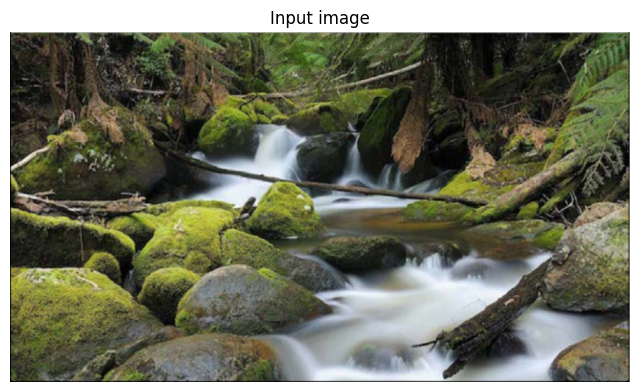

In [2]:
import cv2
img = cv2.imread('./images/input.jpg')
# cv2.imshow('Input image', img)   # <- the manual's lines (external window)
# cv2.waitKey()
show('Input image', img)

In [3]:
import cv2
img = cv2.imread('./images/input.jpg')
print(type(img))
print("shape :", img.shape, " -> (rows, columns, channels)")
print("dtype :", img.dtype, " min/max =", img.min(), img.max())
print("pixel [0,0] in B,G,R order :", img[0, 0])

<class 'numpy.ndarray'>
shape : (458, 812, 3)  -> (rows, columns, channels)
dtype : uint8  min/max = 0 255
pixel [0,0] in B,G,R order : [32 33 31]


## 2. Load an image in grayscale

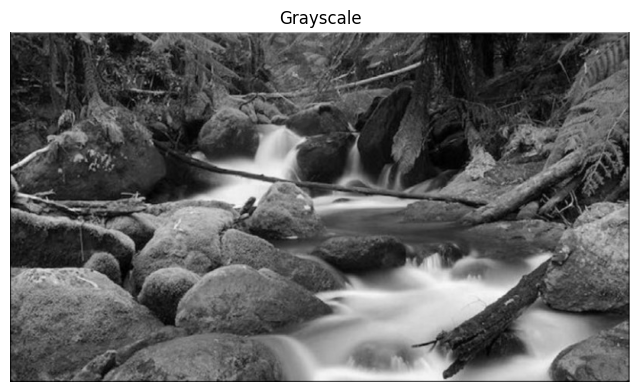

shape : (458, 812)  -> a single channel is left


In [4]:
import cv2
gray_img = cv2.imread('images/input.jpg', cv2.IMREAD_GRAYSCALE)
# cv2.imshow('Grayscale', gray_img)
# cv2.waitKey()
show('Grayscale', gray_img)
print("shape :", gray_img.shape, " -> a single channel is left")

## 3. Save an image

In [5]:
cv2.imwrite('images/output.jpg', gray_img)

# read it back to check that the file was written
saved = cv2.imread('images/output.jpg', cv2.IMREAD_UNCHANGED)
print("written :", saved is not None, " shape =", saved.shape)
print("max difference with gray_img (JPEG is lossy) :",
      int(np.abs(saved.astype(int) - gray_img.astype(int)).max()))

written : True  shape = (458, 812)
max difference with gray_img (JPEG is lossy) : 3


## 4. Convert an image to different color spaces

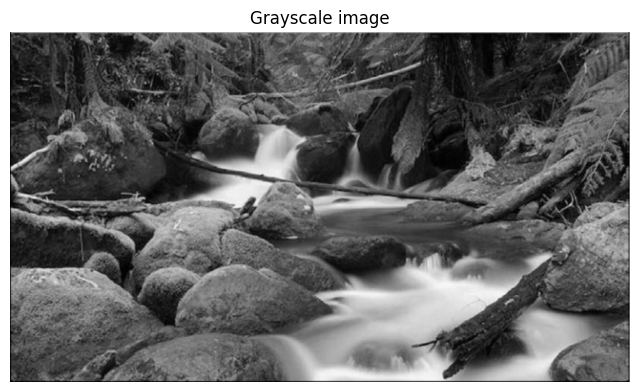

In [6]:
import cv2
img = cv2.imread('./images/input.jpg')
gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
# cv2.imshow('Grayscale image', gray_img)
# cv2.waitKey()
show('Grayscale image', gray_img)

In [7]:
import cv2
# print [x for x in dir(cv2) if x.startswith('COLOR_')]   # <- manual (Python 2 syntax)
color_flags = [x for x in dir(cv2) if x.startswith('COLOR_')]
print(len(color_flags), "color conversion flags, for example :")
print(color_flags[:20])

374 color conversion flags, for example :
['COLOR_BAYER_BG2BGR', 'COLOR_BAYER_BG2BGRA', 'COLOR_BAYER_BG2BGR_EA', 'COLOR_BAYER_BG2BGR_VNG', 'COLOR_BAYER_BG2GRAY', 'COLOR_BAYER_BG2RGB', 'COLOR_BAYER_BG2RGBA', 'COLOR_BAYER_BG2RGB_EA', 'COLOR_BAYER_BG2RGB_VNG', 'COLOR_BAYER_BGGR2BGR', 'COLOR_BAYER_BGGR2BGRA', 'COLOR_BAYER_BGGR2BGR_EA', 'COLOR_BAYER_BGGR2BGR_VNG', 'COLOR_BAYER_BGGR2GRAY', 'COLOR_BAYER_BGGR2RGB', 'COLOR_BAYER_BGGR2RGBA', 'COLOR_BAYER_BGGR2RGB_EA', 'COLOR_BAYER_BGGR2RGB_VNG', 'COLOR_BAYER_GB2BGR', 'COLOR_BAYER_GB2BGRA']


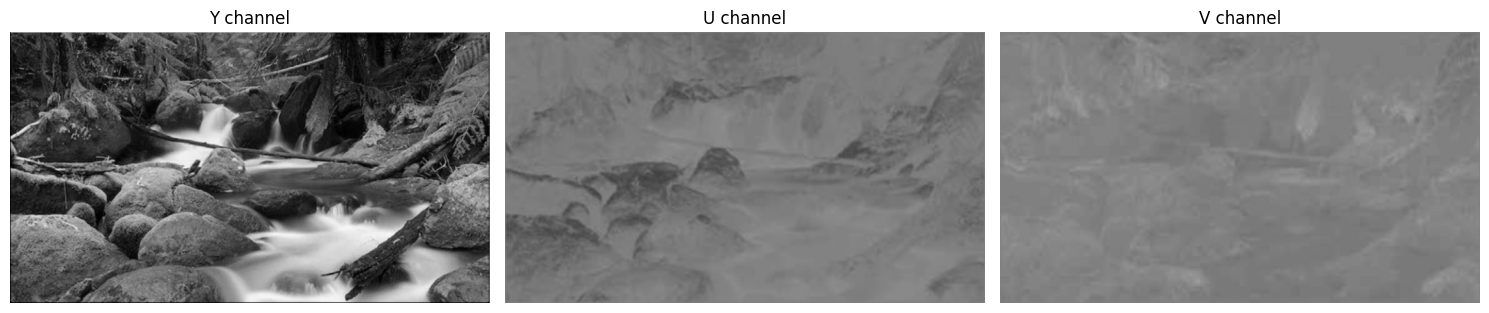

Y : min =   0  max = 253  mean =   90.3  std =  54.9
U : min =  60  max = 144  mean =  119.3  std =  11.7
V : min = 104  max = 159  mean =  128.8  std =   5.8


In [8]:
yuv_img = cv2.cvtColor(img, cv2.COLOR_BGR2YUV)

# cv2.imshow('Y channel', yuv_img[:, :, 0])
# cv2.imshow('U channel', yuv_img[:, :, 1])
# cv2.imshow('V channel', yuv_img[:, :, 2])
# cv2.waitKey()
plt.figure(figsize=(15, 3.5))
for k, name in enumerate(['Y channel', 'U channel', 'V channel']):
    plt.subplot(1, 3, k + 1)
    plt.imshow(yuv_img[:, :, k], cmap='gray', vmin=0, vmax=255)
    plt.title(name)
    plt.axis('off')
plt.tight_layout()
plt.show()

for k, name in enumerate('YUV'):
    ch = yuv_img[:, :, k]
    print(f"{name} : min = {ch.min():3d}  max = {ch.max():3d}  mean = {ch.mean():6.1f}  std = {ch.std():5.1f}")

## 5. Student tasks

### Task 1
Use any image processing library and apply the following geometric transformations over the image.
1. Increase the size of the image.
2. Rotate the image by 120 degrees.
3. Perform Sheer operations over the image.

### Task 2
Use any image processing library and apply the following intensity transformations over the image.
1. Create a Negative Image
2. Log with (choose an appropriate constant for your image)
3. Power law (choose a value for gamma that increases the contrast)

### Task 1 Solution – Geometric transformations

In [9]:
img = cv2.imread('./images/input.jpg')
h, w = img.shape[:2]
print("original size :", w, "x", h)

original size : 812 x 458


#### 1. Increase the size of the image

new size : 1624 x 916  -> 4x more pixels


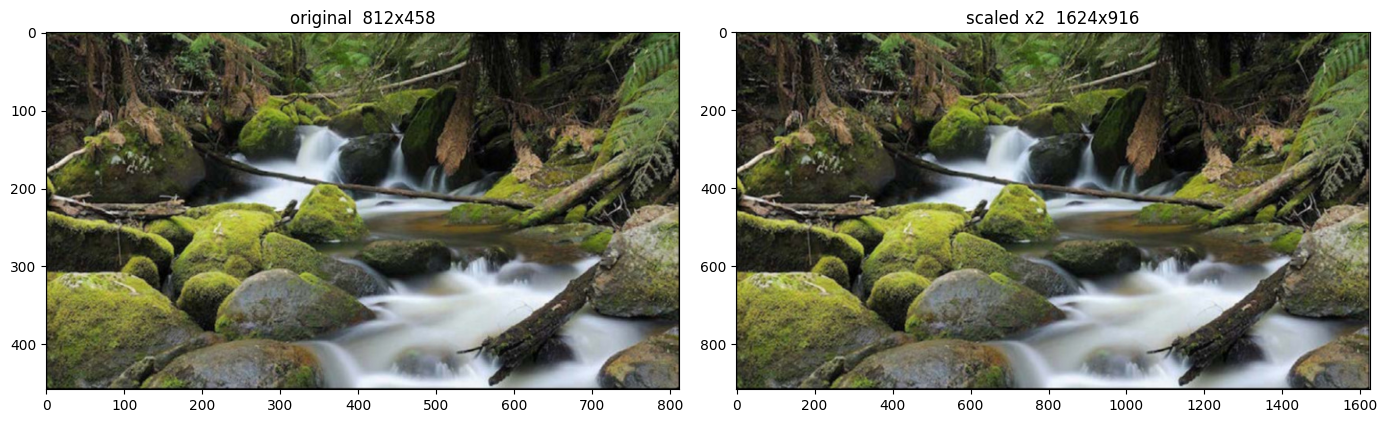

In [10]:
# scale by 2 in both directions -> 4 times more pixels
scale = 2
bigger = cv2.resize(img, None, fx=scale, fy=scale, interpolation=cv2.INTER_CUBIC)
print("new size :", bigger.shape[1], "x", bigger.shape[0],
      f" -> {bigger.shape[0] * bigger.shape[1] / (h * w):.0f}x more pixels")

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title(f'original  {w}x{h}')
plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(bigger, cv2.COLOR_BGR2RGB))
plt.title(f'scaled x{scale}  {bigger.shape[1]}x{bigger.shape[0]}')
plt.tight_layout()
plt.show()

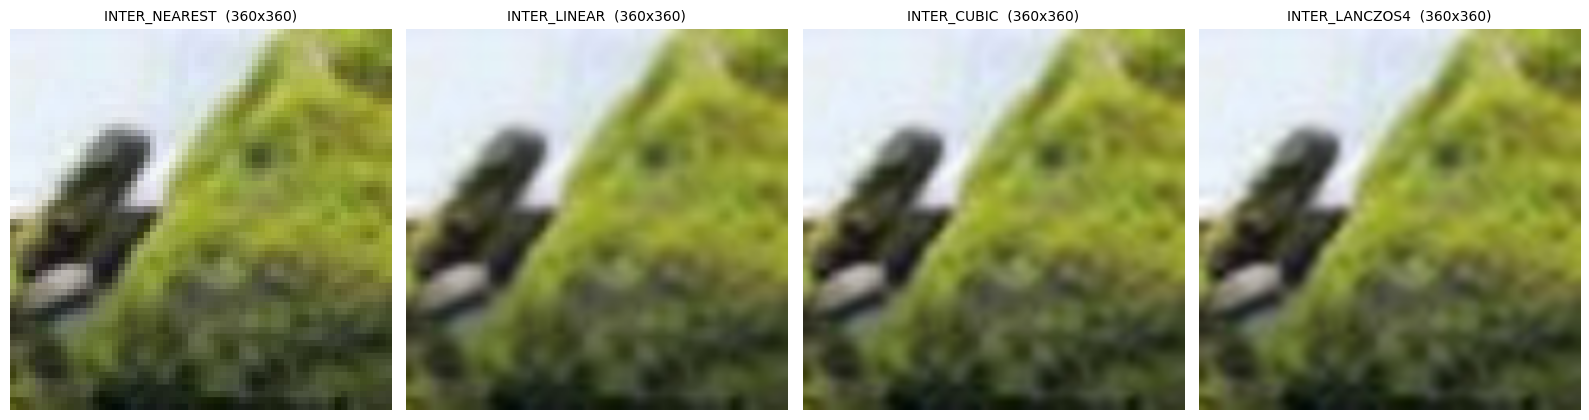

In [11]:
# the interpolation method decides how the new pixels are filled in.
# zoom on a 60x60 crop scaled x6 to see the difference
crop = img[200:260, 300:360]
methods = [('INTER_NEAREST', cv2.INTER_NEAREST), ('INTER_LINEAR', cv2.INTER_LINEAR),
           ('INTER_CUBIC', cv2.INTER_CUBIC), ('INTER_LANCZOS4', cv2.INTER_LANCZOS4)]

plt.figure(figsize=(16, 4.5))
for k, (name, flag) in enumerate(methods):
    up = cv2.resize(crop, None, fx=6, fy=6, interpolation=flag)
    plt.subplot(1, 4, k + 1)
    plt.imshow(cv2.cvtColor(up, cv2.COLOR_BGR2RGB))
    plt.title(f'{name}  ({up.shape[1]}x{up.shape[0]})', fontsize=10)
    plt.axis('off')
plt.tight_layout()
plt.show()

#### 2. Rotate the image by 120 degrees

rotation matrix :
 [[-5.00000e-01  8.66000e-01  4.10680e+02]
 [-8.66000e-01 -5.00000e-01  6.95106e+02]]
canvas needed for the full rotation : 802 x 932


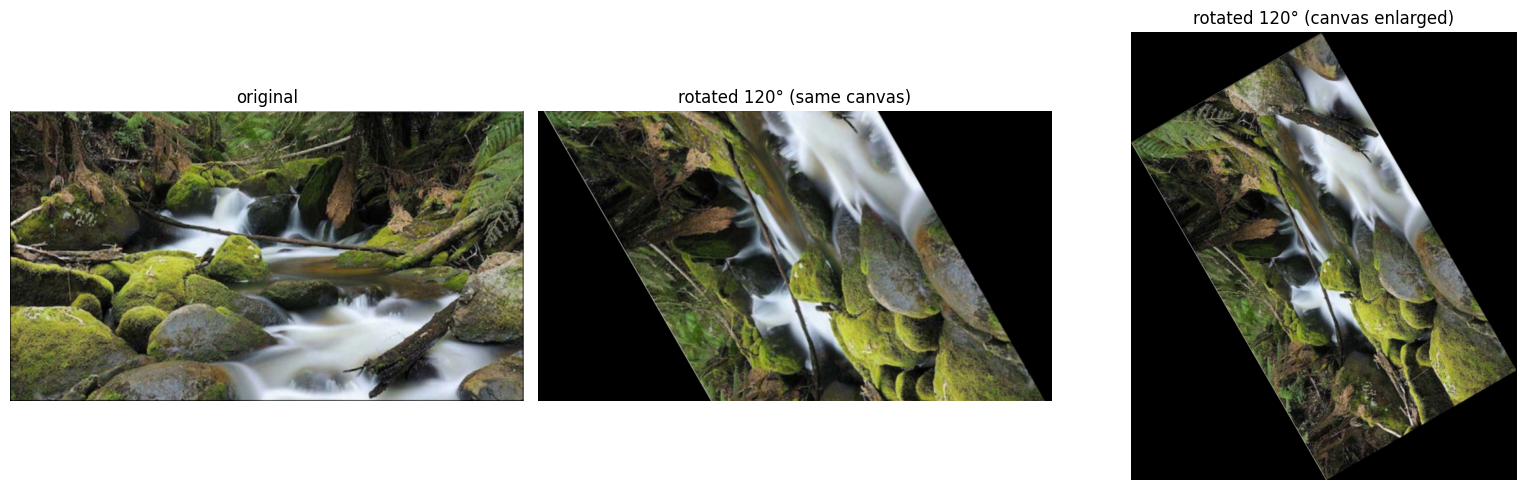

In [12]:
angle = 120
center = (w / 2, h / 2)
M = cv2.getRotationMatrix2D(center, angle, 1.0)     # positive angle = counter-clockwise
print("rotation matrix :\n", M.round(3))

# (a) same canvas size -> the corners are cut off
rotated_crop = cv2.warpAffine(img, M, (w, h))

# (b) enlarge the canvas so the whole rotated image fits
cos, sin = abs(M[0, 0]), abs(M[0, 1])
new_w = int(h * sin + w * cos)
new_h = int(h * cos + w * sin)
M_full = M.copy()
M_full[0, 2] += new_w / 2 - center[0]
M_full[1, 2] += new_h / 2 - center[1]
rotated_full = cv2.warpAffine(img, M_full, (new_w, new_h))
print("canvas needed for the full rotation :", new_w, "x", new_h)

plt.figure(figsize=(16, 5))
for k, (im, t) in enumerate([(img, 'original'),
                             (rotated_crop, f'rotated {angle}° (same canvas)'),
                             (rotated_full, f'rotated {angle}° (canvas enlarged)')]):
    plt.subplot(1, 3, k + 1)
    plt.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
    plt.title(t)
    plt.axis('off')
plt.tight_layout()
plt.show()

#### 3. Shear the image

horizontal shear matrix :
 [[1.  0.4 0. ]
 [0.  1.  0. ]]
vertical shear matrix   :
 [[1.  0.  0. ]
 [0.4 1.  0. ]]


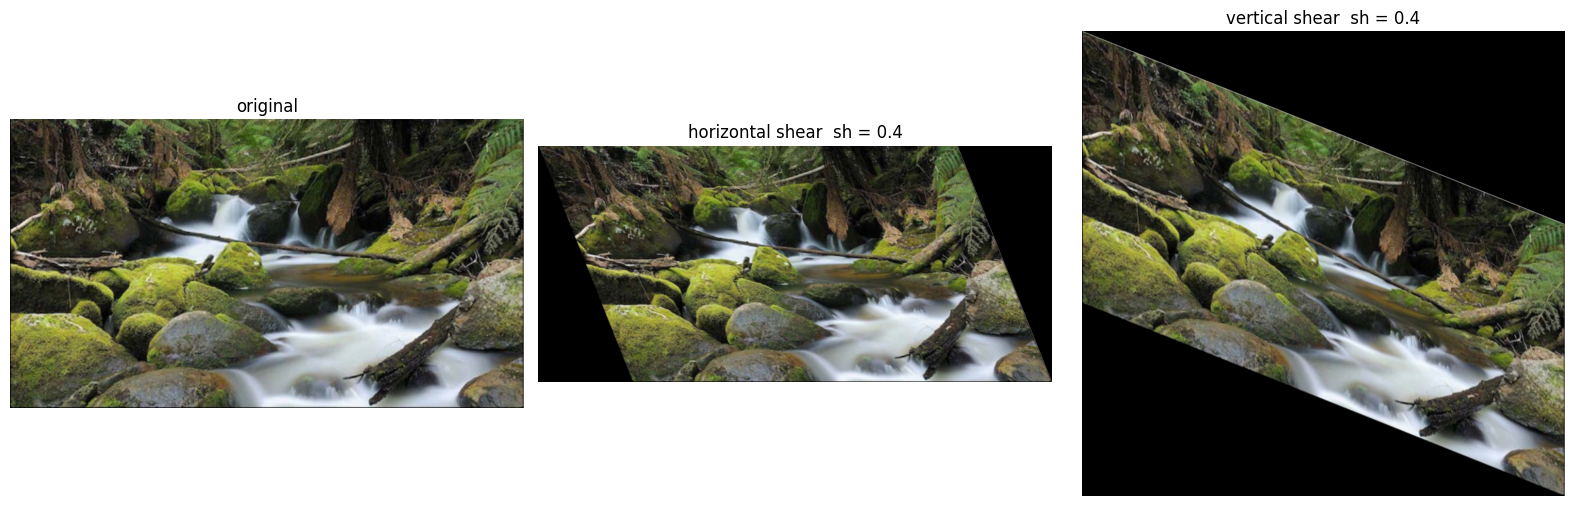

In [13]:
sh = 0.4

# horizontal shear : x' = x + sh * y
M_x = np.float32([[1, sh, 0],
                  [0, 1,  0]])
shear_x = cv2.warpAffine(img, M_x, (int(w + sh * h), h))

# vertical shear : y' = y + sh * x
M_y = np.float32([[1,  0, 0],
                  [sh, 1, 0]])
shear_y = cv2.warpAffine(img, M_y, (w, int(h + sh * w)))

print("horizontal shear matrix :\n", M_x)
print("vertical shear matrix   :\n", M_y)

plt.figure(figsize=(16, 5))
for k, (im, t) in enumerate([(img, 'original'),
                             (shear_x, f'horizontal shear  sh = {sh}'),
                             (shear_y, f'vertical shear  sh = {sh}')]):
    plt.subplot(1, 3, k + 1)
    plt.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
    plt.title(t)
    plt.axis('off')
plt.tight_layout()
plt.show()

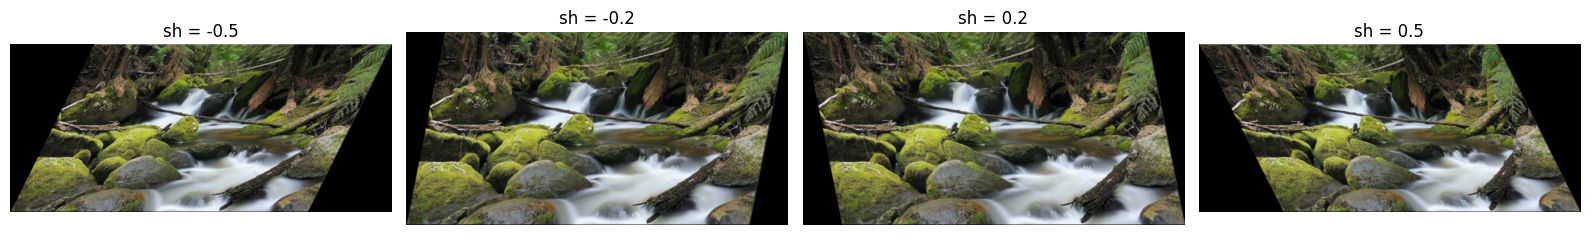

In [14]:
# a few shear factors side by side (negative values lean the other way)
plt.figure(figsize=(16, 4))
for k, s in enumerate([-0.5, -0.2, 0.2, 0.5]):
    M_s = np.float32([[1, s, -s * h if s < 0 else 0], [0, 1, 0]])
    out = cv2.warpAffine(img, M_s, (int(w + abs(s) * h), h))
    plt.subplot(1, 4, k + 1)
    plt.imshow(cv2.cvtColor(out, cv2.COLOR_BGR2RGB))
    plt.title(f'sh = {s}')
    plt.axis('off')
plt.tight_layout()
plt.show()

Explanation: scaling, rotation and shear are all affine transformations, so each one is a 2x3 matrix passed to `cv2.warpAffine()` (or `cv2.resize()` for the scaling). The geometry only moves the pixels, the interpolation decides the new values, and the output canvas has to be enlarged for rotation and shear or part of the image falls outside it.

### Task 2 Solution – Intensity transformations

In [15]:
gray = cv2.imread('./images/input.jpg', cv2.IMREAD_GRAYSCALE)
r = gray.astype(np.float64)          # work in float so nothing wraps around
print("gray image :", gray.shape, " min/max =", gray.min(), gray.max(),
      " mean =", round(float(gray.mean()), 1), " std =", round(float(gray.std()), 1))

gray image : (458, 812)  min/max = 0 253  mean = 90.3  std = 54.9


#### 1. Negative image

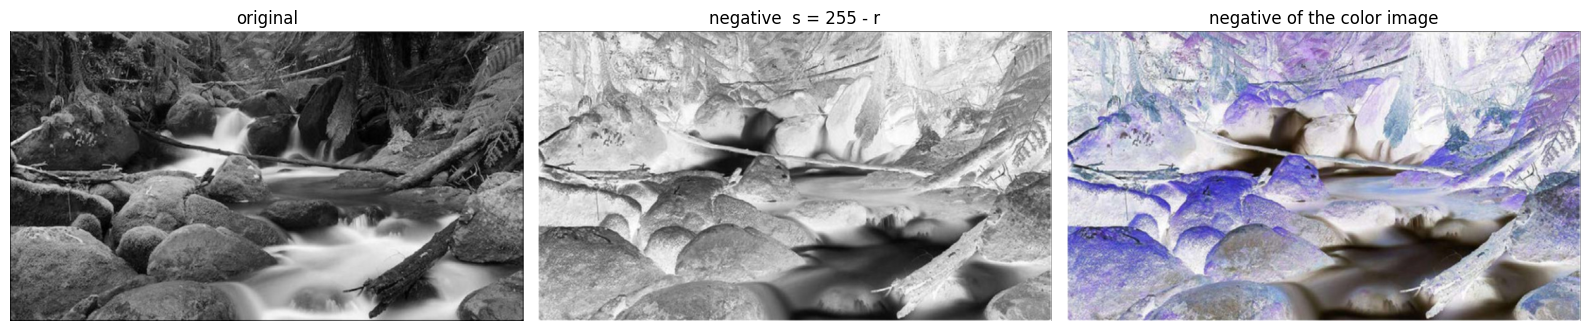

mean original : 90.3  mean negative : 164.7  (sum = 255)
negative of the negative == original : True


In [16]:
# s = (L - 1) - r
negative = (255 - r).astype(np.uint8)
negative_color = 255 - img                     # same thing on the three BGR channels

plt.figure(figsize=(16, 4.5))
for k, (im, t) in enumerate([(gray, 'original'), (negative, 'negative  s = 255 - r')]):
    plt.subplot(1, 3, k + 1)
    plt.imshow(im, cmap='gray', vmin=0, vmax=255)
    plt.title(t)
    plt.axis('off')
plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(negative_color, cv2.COLOR_BGR2RGB))
plt.title('negative of the color image')
plt.axis('off')
plt.tight_layout()
plt.show()

print("mean original :", round(float(gray.mean()), 1), " mean negative :",
      round(float(negative.mean()), 1), " (sum = 255)")
print("negative of the negative == original :", np.array_equal(255 - negative, gray))

#### 2. Log transformation

c = 255 / log(1 + 253) = 46.05


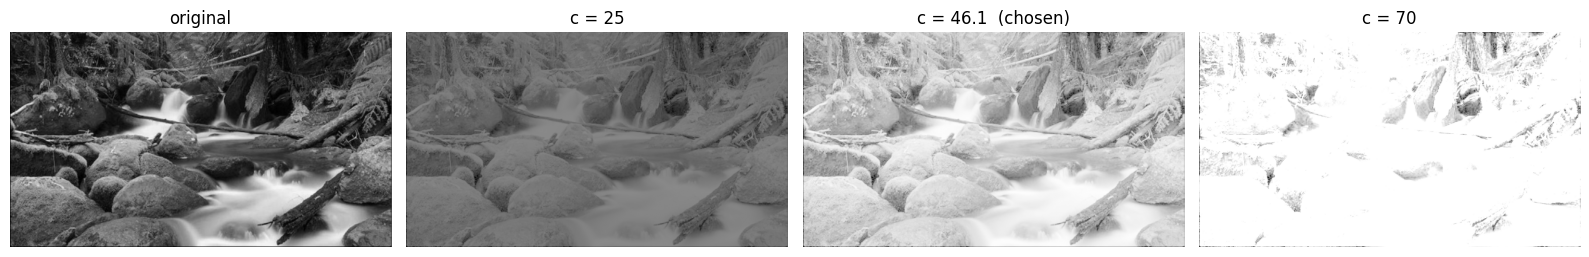

mean original : 90.3  mean log : 197.2
pixels saturated at 255 with c = 70 : 304377 / 371896


In [17]:
# s = c * log(1 + r), c chosen so that the brightest pixel is mapped to 255
c = 255 / np.log(1 + r.max())
print(f"c = 255 / log(1 + {int(r.max())}) = {c:.2f}")

log_img = (c * np.log(1 + r)).astype(np.uint8)

# other constants for comparison : too small -> dark, too large -> saturated
plt.figure(figsize=(16, 4.5))
for k, (cc, t) in enumerate([(None, 'original'), (25, 'c = 25'),
                             (c, f'c = {c:.1f}  (chosen)'), (70, 'c = 70')]):
    out = gray if cc is None else np.clip(cc * np.log(1 + r), 0, 255).astype(np.uint8)
    plt.subplot(1, 4, k + 1)
    plt.imshow(out, cmap='gray', vmin=0, vmax=255)
    plt.title(t)
    plt.axis('off')
plt.tight_layout()
plt.show()

print("mean original :", round(float(gray.mean()), 1), " mean log :", round(float(log_img.mean()), 1))
print("pixels saturated at 255 with c = 70 :",
      int((70 * np.log(1 + r) >= 255).sum()), "/", gray.size)

#### 3. Power law (gamma) transformation

In [18]:
def gamma_transform(image, gamma):
    # s = 255 * (r / 255) ^ gamma   (c = 255 after normalising r to [0, 1])
    return (255 * (image.astype(np.float64) / 255) ** gamma).astype(np.uint8)


# the image is dark : most of the pixels are below 128, so the contrast that matters
# is the one inside that dark region (standard deviation of its gray levels)
dark = gray < 128
print(f"dark pixels : {100 * dark.mean():.1f}% of the image\n")

gammas = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 1.0, 1.5, 2.0, 3.0]
print(f"{'gamma':>6} | {'mean':>6} | {'global std':>10} | {'std of the dark region':>22}")
print('-' * 54)
for g in gammas:
    out = gamma_transform(gray, g)
    print(f"{g:>6} | {out.mean():>6.1f} | {out.std():>10.1f} | {out[dark].std():>22.1f}")

best_gamma = max(gammas, key=lambda g: gamma_transform(gray, g)[dark].std())
print("\ngamma that gives the highest contrast in the dark region :", best_gamma)

dark pixels : 77.5% of the image

 gamma |   mean | global std | std of the dark region
------------------------------------------------------
   0.3 |  178.0 |       37.0 |                   29.7
   0.4 |  159.6 |       43.1 |                   33.2
   0.5 |  143.6 |       47.4 |                   35.1
   0.6 |  129.9 |       50.4 |                   35.8
   0.7 |  117.8 |       52.5 |                   35.8
   0.8 |  107.2 |       53.8 |                   35.0
   1.0 |   90.3 |       54.9 |                   32.7


   1.5 |   60.6 |       53.1 |                   24.9


   2.0 |   43.3 |       49.3 |                   17.7
   3.0 |   25.2 |       41.6 |                    8.4

gamma that gives the highest contrast in the dark region : 0.6


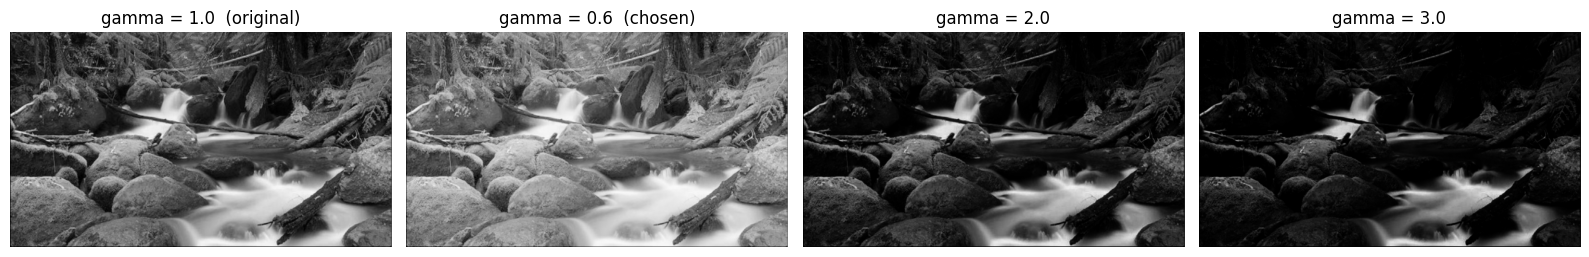

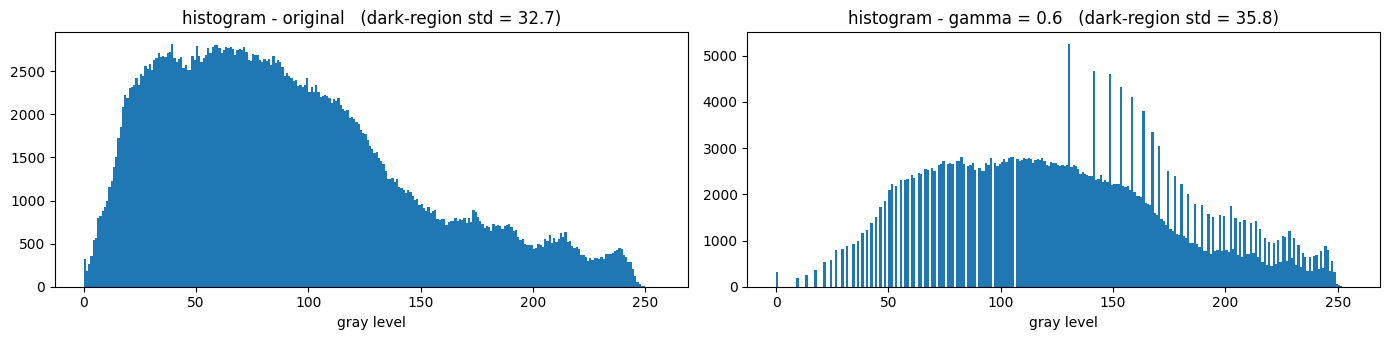

In [19]:
gamma_img = gamma_transform(gray, best_gamma)

plt.figure(figsize=(16, 4.5))
for k, g in enumerate([1.0, best_gamma, 2.0, 3.0]):
    plt.subplot(1, 4, k + 1)
    plt.imshow(gamma_transform(gray, g), cmap='gray', vmin=0, vmax=255)
    plt.title(f'gamma = {g}' + ('  (original)' if g == 1 else '  (chosen)' if g == best_gamma else ''))
    plt.axis('off')
plt.tight_layout()
plt.show()

# histograms : the chosen gamma spreads the dark gray levels over a wider range
plt.figure(figsize=(14, 3.5))
for k, (im, t) in enumerate([(gray, 'original'), (gamma_img, f'gamma = {best_gamma}')]):
    plt.subplot(1, 2, k + 1)
    plt.hist(im.ravel(), bins=256, range=(0, 256))
    plt.title(f'histogram - {t}   (dark-region std = {im[dark].std():.1f})')
    plt.xlabel('gray level')
plt.tight_layout()
plt.show()

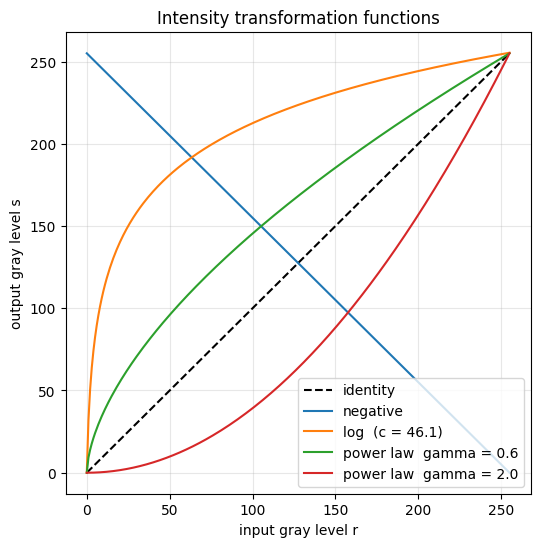

In [20]:
# the three transformation curves s = T(r)
rr = np.arange(256)
plt.figure(figsize=(6, 6))
plt.plot(rr, rr, 'k--', label='identity')
plt.plot(rr, 255 - rr, label='negative')
plt.plot(rr, c * np.log(1 + rr), label=f'log  (c = {c:.1f})')
for g in [best_gamma, 2.0]:
    plt.plot(rr, 255 * (rr / 255) ** g, label=f'power law  gamma = {g}')
plt.xlabel('input gray level r')
plt.ylabel('output gray level s')
plt.title('Intensity transformation functions')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

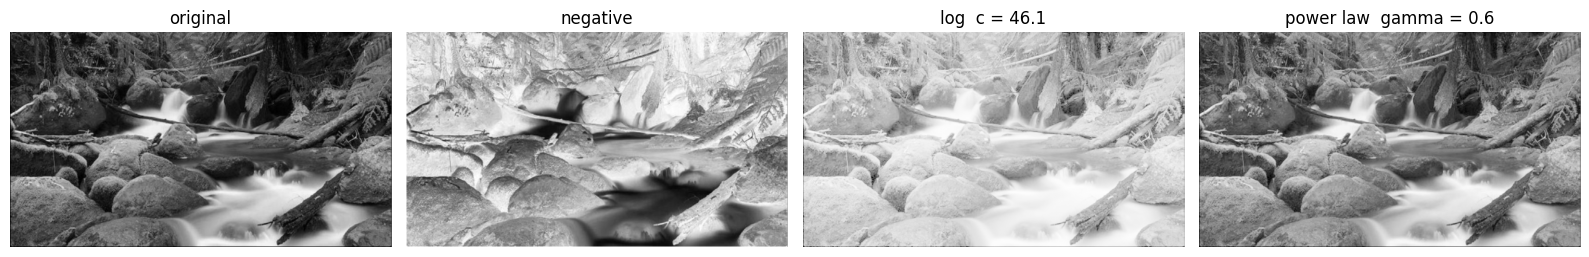

In [21]:
# summary of the three intensity transformations
plt.figure(figsize=(16, 4.5))
for k, (im, t) in enumerate([(gray, 'original'), (negative, 'negative'),
                             (log_img, f'log  c = {c:.1f}'),
                             (gamma_img, f'power law  gamma = {best_gamma}')]):
    plt.subplot(1, 4, k + 1)
    plt.imshow(im, cmap='gray', vmin=0, vmax=255)
    plt.title(t)
    plt.axis('off')
plt.tight_layout()
plt.show()

Explanation: the input image is dark (mean around 90, with almost 78% of the pixels below 128), so most of its gray levels are packed in the lower part of the range. A gamma smaller than 1 has a slope larger than 1 for dark inputs, so it stretches exactly that part and raises the contrast of the rocks and the forest, at the price of compressing the already bright water. A gamma larger than 1 does the opposite and makes the image darker and flatter. The log constant was chosen as 255 / log(1 + max) so the output uses the full 0-255 range without saturating.